In [1]:

import os
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers
from matplotlib import pyplot as plt
import numpy as np
# from keras.preprocessing.image import ImageDataGenerator


2026-02-13 06:04:10.117533: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
devices=tf.config.experimental.list_physical_devices()
devices

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
IMG_SIZE = 128   # or whatever you trained with
BATCH_SIZE=64
VAL_SIZE = 10000
RANDOM_SEED=420
# tf.random.set_seed(RANDOM_SEED)
# np.random.seed(RANDOM_SEED)


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Train shape:", x_train.shape, y_train.shape)
print("Test  shape:", x_test.shape, y_test.shape)

Train shape: (60000, 28, 28) (60000,)
Test  shape: (10000, 28, 28) (10000,)


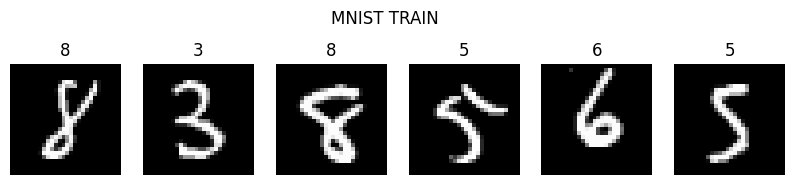

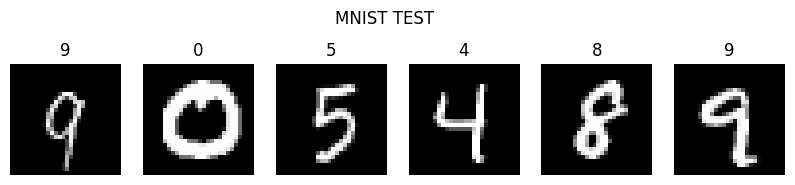

In [4]:
def visualize_data(x, y, title, n=6):
    idx = np.random.choice(len(x), n, replace=False)

    plt.figure(figsize=(10,4))
    for i, j in enumerate(idx):
        plt.subplot(2,6,i+1)
        plt.imshow(x[j], cmap="gray")
        plt.title(int(y[j]))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()



visualize_data(x_train, y_train, "MNIST TRAIN")
visualize_data(x_test,  y_test,  "MNIST TEST")


In [5]:
def class_distribution(y, name):
    counts = np.bincount(y, minlength=10)
    total = len(y)

    print(f"\n{name}")
    for i in range(10):
        print(f"Digit {i}: {counts[i]:5d}  ({counts[i]/total:.3f})")
class_distribution(y_train, "TRAIN")
class_distribution(y_test,  "TEST")


TRAIN
Digit 0:  5923  (0.099)
Digit 1:  6742  (0.112)
Digit 2:  5958  (0.099)
Digit 3:  6131  (0.102)
Digit 4:  5842  (0.097)
Digit 5:  5421  (0.090)
Digit 6:  5918  (0.099)
Digit 7:  6265  (0.104)
Digit 8:  5851  (0.098)
Digit 9:  5949  (0.099)

TEST
Digit 0:   980  (0.098)
Digit 1:  1135  (0.114)
Digit 2:  1032  (0.103)
Digit 3:  1010  (0.101)
Digit 4:   982  (0.098)
Digit 5:   892  (0.089)
Digit 6:   958  (0.096)
Digit 7:  1028  (0.103)
Digit 8:   974  (0.097)
Digit 9:  1009  (0.101)


In [6]:
# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Flatten (28x28 → 784)
x_train = x_train.reshape(len(x_train), -1)
x_test  = x_test.reshape(len(x_test),  -1)

# Labels MUST be integers
y_train = y_train.astype("int32")
y_test  = y_test.astype("int32")



In [7]:

perm = tf.random.shuffle(tf.range(len(x_train)), seed=RANDOM_SEED)

x_train = tf.gather(x_train, perm)
y_train = tf.gather(y_train, perm)

x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

x_train = x_train[:-VAL_SIZE]
y_train = y_train[:-VAL_SIZE]

print("Train:", x_train.shape, y_train.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)


2026-02-13 06:04:14.416691: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15305 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0


Train: (50000, 784) (50000,)
Val  : (10000, 784) (10000,)
Test : (10000, 784) (10000,)


In [8]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_val   = tf.keras.utils.to_categorical(y_val, 10)
y_test  = tf.keras.utils.to_categorical(y_test, 10)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000, seed=RANDOM_SEED, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE)

In [10]:

model = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:

class MetricsStopping(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.98 and logs.get('val_accuracy') > 0.98):
            self.model.stop_training = True
            print("Sufficient Metrics Reached!")


In [14]:
print("Fit model on training data")
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=MetricsStopping()
)

Fit model on training data
Epoch 1/10


2026-02-13 06:04:16.630742: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x712704a10fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-13 06:04:16.630784: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-02-13 06:04:16.637723: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-13 06:04:16.655893: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8905
2026-02-13 06:04:16.838571: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 [==============================] - 6s 6ms/step - loss: 0.3041 - accuracy: 0.9123 - val_loss: 0.1550 - val_accuracy: 0.9517
Epoch 2/10
782/782 [==============================] - 4s 5ms/step - loss: 0.1248 - accuracy: 0.9620 - val_loss: 0.1114 - val_accuracy: 0.9677
Epoch 3/10
782/782 [==============================] - 4s 6ms/step - loss: 0.0871 - accuracy: 0.9742 - val_loss: 0.0964 - val_accuracy: 0.9695
Epoch 4/10
782/782 [==============================] - 5s 6ms/step - loss: 0.0661 - accuracy: 0.9795 - val_loss: 0.0897 - val_accuracy: 0.9725
Epoch 5/10
782/782 [==============================] - 4s 6ms/step - loss: 0.0502 - accuracy: 0.9842 - val_loss: 0.0823 - val_accuracy: 0.9748
Epoch 6/10
782/782 [==============================] - 4s 6ms/step - loss: 0.0393 - accuracy: 0.9874 - val_loss: 0.0800 - val_accuracy: 0.9766
Epoch 7/10
782/782 [==============================] - 4s 6ms/step - loss: 0.0310 - accuracy: 0.9901 - val_loss: 0.0886 - val_accuracy: 0.9733
Epoch 8/10
782/78

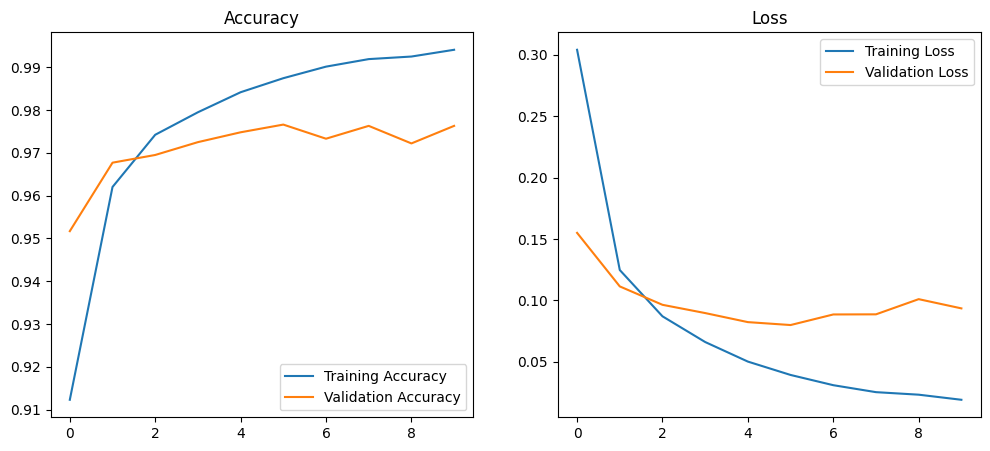

In [15]:
import matplotlib.pyplot as plt

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Loss")

plt.show()


In [18]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

  1/157 [..............................] - ETA: 3s - loss: 0.0069 - accuracy: 1.0000

157/157 [==============================] - 0s 3ms/step - loss: 0.0903 - accuracy: 0.9763
Test accuracy: 0.9763000011444092


In [17]:
# model.save("mymodel.h5")